Використай цей шаблон в роботі з датасетом.    
Ти можеш додавати комірки за потреби, але не змінюй структуру і послідовність питань.    
Обмежся функціями з наведених бібліотек.

In [9]:
import json
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

1. Переглянь список .json файлів, доступних за адресою https://github.com/prust/wikipedia-movie-data/tree/master.    
Відкрий будь-який файл, що містить у своїй назві рік і ознайомся з його структурою.    
Тепер сформуй список файлів, які ти будеш завантажувати.    
Для формування послідовності слід використати функцію numpy.arange.    
Довжина послідовності має становити не менше 5 датасетів(наприклад з 1960 по 2000  рік включно).    
Повну адресу сформуй через конкатенацію рядків.

In [10]:
# Для формування послідовності слід використати функцію numpy.arange

years = np.arange(1950, 2000, 10)

print(years)

[1950 1960 1970 1980 1990]


In [13]:
# Тепер сформуй список файлів, які ти будеш завантажувати

files = [f"movies-{str(year)}s.json" for year in years]

print(files)

['movies-1950s.json', 'movies-1960s.json', 'movies-1970s.json', 'movies-1980s.json', 'movies-1990s.json']


In [14]:
# Повну адресу сформуй через конкатенацію рядків
# Підказка: для формування повної адреси файлу слід комбінувати частини:
# json_dir = "<https://raw.githubusercontent.com/prust/wikipedia-movie-data/refs/heads/master/>"
# file = "movies-60s.json”(наприклад)
# file_path = json_dir + file

json_dir = "https://raw.githubusercontent.com/prust/wikipedia-movie-data/refs/heads/master/"
file_paths = [json_dir + i for i in files]

print(file_paths)

['https://raw.githubusercontent.com/prust/wikipedia-movie-data/refs/heads/master/movies-1950s.json', 'https://raw.githubusercontent.com/prust/wikipedia-movie-data/refs/heads/master/movies-1960s.json', 'https://raw.githubusercontent.com/prust/wikipedia-movie-data/refs/heads/master/movies-1970s.json', 'https://raw.githubusercontent.com/prust/wikipedia-movie-data/refs/heads/master/movies-1980s.json', 'https://raw.githubusercontent.com/prust/wikipedia-movie-data/refs/heads/master/movies-1990s.json']


2. Тепер послідовність дій наступна.   
Слід пройти по всім обраним тобою файлам, прочитати кожен, як json об'єкт.        
Позбутись зайвих стовпців: ['href', 'extract', 'thumbnail', 'thumbnail_width', 'thumbnail_height'].     
Залишити лише повні рядки(рядки без пропущених значень).     
Об'єднати інформацію з усіх файлів в єдиний датасет.

In [15]:
# перевірка_N(+)
url_50 = "https://raw.githubusercontent.com/prust/wikipedia-movie-data/refs/heads/master/movies-1950s.json"

response = requests.get(url_50)

if response.status_code == 200:
    dec_50 = response.json()
else:
    print('error')

print(type(dec_50))
print(len(dec_50))

<class 'list'>
3151


*зформавані посилення не працювали через помилку в підказці в завданні 'file = "movies-60s.json”(наприклад)'. назви файлів з повним роком: ...1960s.json* 

In [22]:
five_decades = None

for file in file_paths:
    response = requests.get(file) # пройти по всім обраним тобою файлам, прочитати кожен, як json об'єкт
    
    if response.status_code != 200:
        print('error')
        continue
    
    df_decade = pd.DataFrame(response.json())
    df_decade = df_decade.drop(columns=['href', 'extract', 'thumbnail', 'thumbnail_width', 'thumbnail_height']) #Позбутись зайвих стовпців: ['href', 'extract', 'thumbnail', 'thumbnail_width', 'thumbnail_height']
    df_decade = df_decade.dropna() # Залишити лише повні рядки(рядки без пропущених значень)

    if five_decades is None:
        five_decades = df_decade # якщо у нас перший прогон
    else:
        five_decades = pd.concat([five_decades, df_decade], ignore_index=True) # Об'єднати інформацію з усіх файлів в єдиний датасет

five_decades.sample(7)

,title,year,cast,genres
8516,Old Gringo,1989,"[Jane Fonda, Gregory Peck, Jimmy Smits]","[Drama, Adventure, Romance]"
398,The Invisible Monster,1950,"[Richard Webb, Aline Towne]",[Adventure]
10000,Free Willy 2: The Adventure Home,1995,"[Francis Capra, Michael Madsen]","[Adventure, Family, Drama]"
9457,Happily Ever After,1993,"[Irene Cara, Edward Asner, Carol Channing]","[Animated, Fantasy, Musical]"
8888,Vital Signs,1990,"[Adrian Pasdar, Diane Lane, William Devane, Ji...","[Comedy, Drama]"
7942,Snow White,1987,[Diana Rigg],"[Family, Fantasy, Musical]"
917,Bloodhounds of Broadway,1952,"[Mitzi Gaynor, Scott Brady]",[Musical]


3. Перевір розмір фінального датасету. Він має включати 4(чотири) стовпчика. Кількість рядків залежить від обраної кількості файлів. Збережи собі копію у вигляді csv або json файлу. Це убезпечить тебе від форс-мажорів.

In [31]:
# Перевір розмір фінального датасету. Він має включати 4(чотири) стовпчика
print(f"Shape after removing columns and na: {five_decades.shape}")

Shape after removing columns and na: (11471, 4)


In [36]:
# Збережи собі копію у вигляді csv або json файлу

five_decades.to_csv('movies_list_50_90.csv', index = False)

4. Для json файлу не варто використовувати метод describe. Файл містить вкладені структури.    
Перевір вміст перших рядочків і використай метод info.

In [33]:
display(five_decades.head())
five_decades.info()

,title,year,cast,genres
0,711 Ocean Drive,1950,"[Edmond O'Brien, Joanne Dru, Dorothy Patrick]","[Crime, Drama, Noir]"
1,Abbott and Costello in the Foreign Legion,1950,"[Abbott and Costello, Patricia Medina]",[Comedy]
2,Across the Badlands,1950,"[Charles Starrett, Smiley Burnette]",[Western]
3,The Admiral Was a Lady,1950,"[Edmond O'Brien, Wanda Hendrix, Steve Brodie]",[Comedy]
4,All About Eve,1950,"[Bette Davis, Anne Baxter, Gary Merrill, Celes...",[Drama]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11471 entries, 0 to 11470
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   11471 non-null  object
 1   year    11471 non-null  int64 
 2   cast    11471 non-null  object
 3   genres  11471 non-null  object
dtypes: int64(1), object(3)
memory usage: 358.6+ KB


5. Тепер слід попрацювати з жанрами.    
Віднайди топ 10 жанрів за кількістю фільмів.    
Побудуй стовпчикову та кругову діаграму, а також виведи на екран підсумкову таблицю.

In [35]:
five_decades['genres'].value_counts()

genres
[Drama]                                           1191
[Comedy]                                           977
[Western]                                          934
[Horror]                                           282
[Adventure]                                        237
                                                  ... 
[Comedy, Horror, Crime, Teen]                        1
[Animated, Science Fiction, Drama, Family]           1
[Action, Crime, Drama, Martial Arts, Thriller]       1
[Family, Animated, Musical]                          1
[Drama, Erotic, Mystery]                             1
Name: count, Length: 1407, dtype: int64

In [39]:
five_decades['genres'].apply(type).value_counts()

genres
<class 'list'>    11471
Name: count, dtype: int64

In [48]:
t10_genres = five_decades['genres'].explode().value_counts().head(10)
t10_genres

genres
Drama              3748
Comedy             3310
Western            1250
Crime              1042
Action              961
Horror              929
Thriller            925
Romance             828
Adventure           741
Science Fiction     722
Name: count, dtype: int64

In [49]:
# виведи на екран підсумкову таблицю
t10_genres = t10_genres.reset_index()
display(t10_genres)

,genres,count
0,Drama,3748
1,Comedy,3310
2,Western,1250
3,Crime,1042
4,Action,961
5,Horror,929
6,Thriller,925
7,Romance,828
8,Adventure,741
9,Science Fiction,722


In [64]:
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 100

C:\Users\konst\AppData\Local\Temp\ipykernel_12120\1911940237.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(t10_genres.genres, rotation=45)


Text(0.0, 1.0, 'Share by Genre')

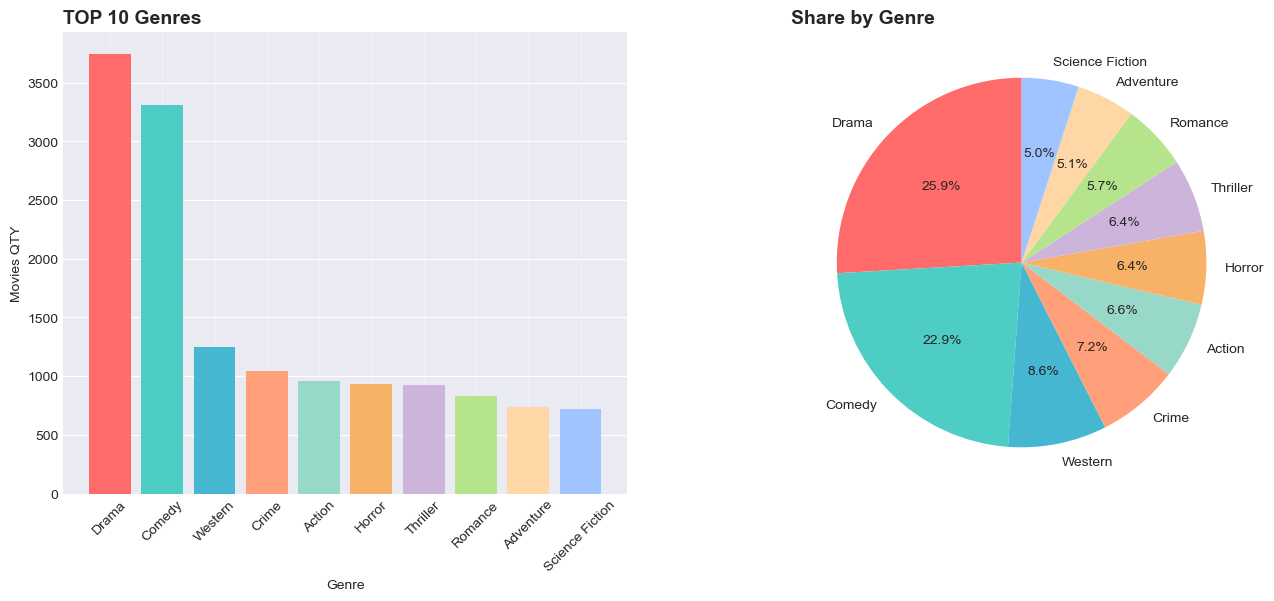

In [108]:
#Побудуй стовпчикову та кругову діаграму
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(t10_genres['genres'], t10_genres['count'],
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7B267', '#CDB4DB', '#B5E48C', '#FFD6A5', '#A0C4FF'])
axes[0].set_title('TOP 10 Genres', fontsize=14, fontweight='bold', loc = 'left')
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('Movies QTY')
axes[0].set_xticklabels(t10_genres.genres, rotation=45)
axes[0].grid(alpha=0.3, axis='x')

axes[1].pie(t10_genres['count'], labels=t10_genres.genres, autopct='%1.1f%%', startangle=90,
           colors=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7B267',  '#CDB4DB', '#B5E48C', '#FFD6A5', '#A0C4FF'])
axes[1].set_title('Share by Genre', fontsize=14, fontweight='bold', loc = 'left')

6. Тепер вибери 3 найпопулярніших жанри і подивись, як змінювалась їх популярність впродовж обраного тобою часового періода.     
Для цього підрахуй кількість фільмів в кожному жанрі за кожен рік спостереження.    
Виведи результат у вигляді лінійного графіка.

In [111]:
# Тепер вибери 3 найпопулярніших жанри 
t3_gen = ['Drama', 'Comedy', 'Western']

t3_gen_years = five_decades.explode('genres')[five_decades.explode('genres')['genres'].isin(t3_gen)]
t3_gen_years['genres'].value_counts()

genres
Drama      3748
Comedy     3310
Western    1250
Name: count, dtype: int64

In [112]:
t3_gen_years.head(7)

,title,year,cast,genres
0,711 Ocean Drive,1950,"[Edmond O'Brien, Joanne Dru, Dorothy Patrick]",Drama
1,Abbott and Costello in the Foreign Legion,1950,"[Abbott and Costello, Patricia Medina]",Comedy
2,Across the Badlands,1950,"[Charles Starrett, Smiley Burnette]",Western
3,The Admiral Was a Lady,1950,"[Edmond O'Brien, Wanda Hendrix, Steve Brodie]",Comedy
4,All About Eve,1950,"[Bette Davis, Anne Baxter, Gary Merrill, Celes...",Drama
5,Ambush,1950,"[Robert Taylor, John Hodiak, Arlene Dahl]",Western
7,Annie Get Your Gun,1950,"[Betty Hutton, Howard Keel]",Comedy


In [113]:
# підрахуй кількість фільмів в кожному жанрі за кожен рік спостереження
t3_gen_over_time = t3_gen_years.pivot_table(
    # columns=['year', 'genres'],
    index='year',
    columns= 'genres',
    values='title',
    aggfunc='count',
)

t3_gen_over_time.head(7)

genres,Comedy,Drama,Western
year,,,
1950,82,79,130
1951,85,92,108
1952,78,83,105
1953,58,88,85
1954,28,63,66
1955,34,81,62
1956,41,87,75


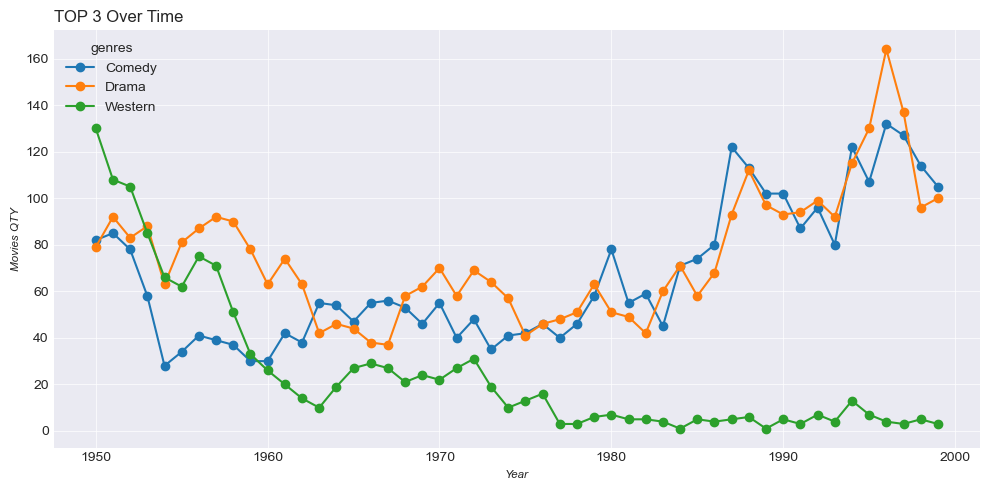

In [114]:
# Виведи результат у вигляді лінійного графіка
t3_gen_over_time.plot(figsize=(10,5), marker='o')
plt.xlabel('Year', fontsize='small', fontstyle='italic')
plt.ylabel('Movies QTY', fontsize='small', fontstyle='italic')
# plt.legend (['Comedy', 'Drama', 'Western'], loc = 'lower right')
plt.title('TOP 3 Over Time', fontsize='large', loc='left')
plt.grid(alpha=0.7)

plt.tight_layout()
plt.show()

7. Тепер слід попрацювати з акторами.     
Віднайди топ 10 акторів за кількістю фільмів.    
Побудуй стовпчикову або кругову діаграму, а також виведи на екран підсумукову таблицю.

In [94]:
#Віднайди топ 10 акторів за кількістю фільмів
t10_actor = five_decades['cast'].explode().value_counts().head(10)
t10_actor

cast
Gene Hackman       63
Robert Mitchum     62
Charles Bronson    59
Walter Matthau     58
Kirk Douglas       57
Glenn Ford         56
Charlton Heston    55
Tony Curtis        55
Burt Lancaster     55
Robert Duvall      55
Name: count, dtype: int64

In [95]:
# виведи на екран підсумкову таблицю
t10_actor = t10_actor.reset_index()
display(t10_actor)

,cast,count
0,Gene Hackman,63
1,Robert Mitchum,62
2,Charles Bronson,59
3,Walter Matthau,58
4,Kirk Douglas,57
5,Glenn Ford,56
6,Charlton Heston,55
7,Tony Curtis,55
8,Burt Lancaster,55
9,Robert Duvall,55


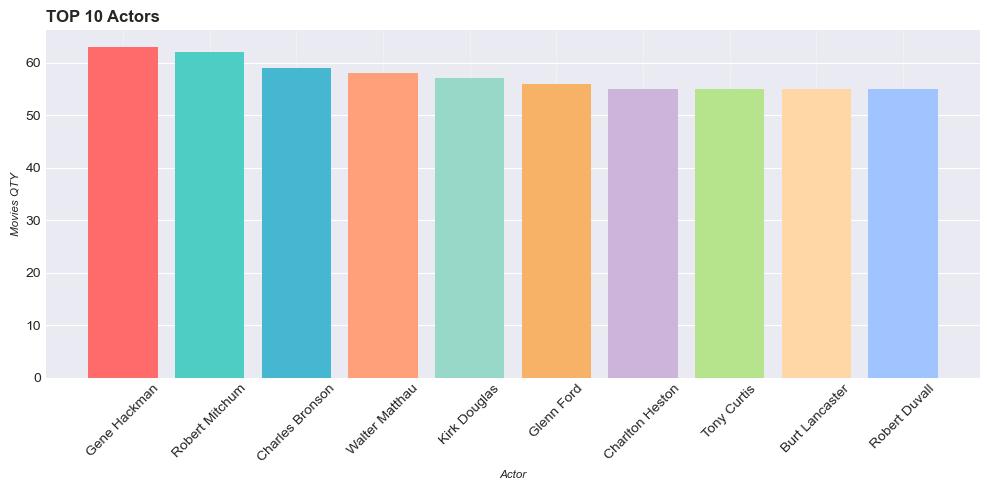

In [106]:
# Побудуй стовпчикову або кругову діаграму
plt.figure(figsize=(10, 5))

plt.bar(t10_actor['cast'], t10_actor['count'],
        # figsize=(10,5),
        color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7B267', '#CDB4DB', '#B5E48C', '#FFD6A5', '#A0C4FF'])
plt.title('TOP 10 Actors', fontsize='large', loc='left', fontweight='bold')
plt.xlabel('Actor', fontsize='small', fontstyle='italic')
plt.ylabel('Movies QTY', fontsize='small', fontstyle='italic')
plt.xticks(t10_actor.cast, rotation=45)
plt.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

8. Тепер вибери 3 найпопулярніших актори і подивись, як змінювалась їх популярність впродовж обраного тобою часового періода.
Для цього підрахуй кількість фільмів для кожного актора за кожен рік спостереження.    
Виведи результат у вигляді лінійного графіка.

In [109]:
five_decades.head(7)

,title,year,cast,genres
0,711 Ocean Drive,1950,"[Edmond O'Brien, Joanne Dru, Dorothy Patrick]","[Crime, Drama, Noir]"
1,Abbott and Costello in the Foreign Legion,1950,"[Abbott and Costello, Patricia Medina]",[Comedy]
2,Across the Badlands,1950,"[Charles Starrett, Smiley Burnette]",[Western]
3,The Admiral Was a Lady,1950,"[Edmond O'Brien, Wanda Hendrix, Steve Brodie]",[Comedy]
4,All About Eve,1950,"[Bette Davis, Anne Baxter, Gary Merrill, Celes...",[Drama]
5,Ambush,1950,"[Robert Taylor, John Hodiak, Arlene Dahl]",[Western]
6,American Guerrilla in the Philippines,1950,"[Tyrone Power, Micheline Presle]",[War]


In [116]:
# Тепер вибери 3 найпопулярніших актори
t3_act = ['Gene Hackman', 'Robert Mitchum', 'Charles Bronson']

t3_act_years = five_decades.explode('cast')[five_decades.explode('cast')['cast'].isin(t3_act)]
t3_act_years['cast'].value_counts()

cast
Gene Hackman       63
Robert Mitchum     62
Charles Bronson    59
Name: count, dtype: int64

In [117]:
t3_act_years.head(7)

,title,year,cast,genres
375,Where Danger Lives,1950,Robert Mitchum,"[Noir, Thriller]"
588,His Kind of Woman,1951,Robert Mitchum,[Noir]
667,My Forbidden Past,1951,Robert Mitchum,"[Drama, Historical, Noir]"
709,The Racket,1951,Robert Mitchum,"[Noir, Drama]"
884,Angel Face,1952,Robert Mitchum,[Noir]
1049,The Lusty Men,1952,Robert Mitchum,[Western]
1052,Macao,1952,Robert Mitchum,"[Noir, Adventure]"


In [121]:
# підрахуй кількість фільмів для кожного актора за кожен рік спостереження
t3_act_over_time = t3_act_years.pivot_table(
    index='year',
    columns= 'cast',
    values='title',
    aggfunc='count',
)

t3_act_over_time.sample(7)

cast,Charles Bronson,Gene Hackman,Robert Mitchum
year,,,
1989,1.0,1.0,NaN
1959,NaN,NaN,2.0
1956,1.0,NaN,2.0
1990,NaN,3.0,NaN
1982,1.0,NaN,1.0
1975,3.0,4.0,1.0
1957,NaN,NaN,3.0


In [124]:
t3_act_over_time = t3_act_over_time.fillna(0)
t3_act_over_time.head(7)

cast,Charles Bronson,Gene Hackman,Robert Mitchum
year,,,
1950,0.0,0.0,1.0
1951,0.0,0.0,3.0
1952,0.0,0.0,4.0
1953,0.0,0.0,3.0
1954,1.0,0.0,3.0
1955,1.0,0.0,3.0
1956,1.0,0.0,2.0


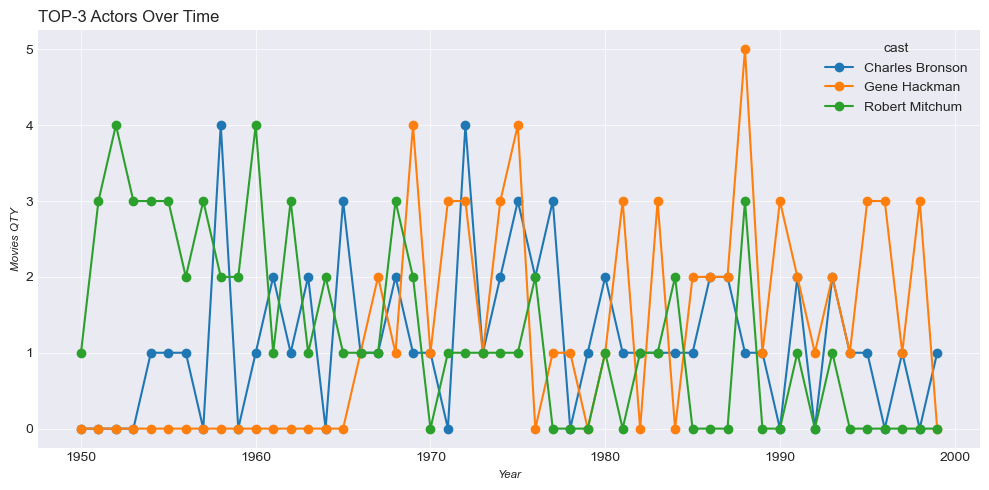

In [123]:
#Виведи результат у вигляді лінійного графіка
t3_act_over_time.plot(figsize=(10,5), marker='o')
plt.xlabel('Year', fontsize='small', fontstyle='italic')
plt.ylabel('Movies QTY', fontsize='small', fontstyle='italic')
# plt.legend (['Charles Bronson', 'Gene Hackman', 'Robert Mitchum'], loc = 'lower right')
plt.title('TOP-3 Actors Over Time', fontsize='large', loc='left')
plt.grid(alpha=0.7)

plt.tight_layout()
plt.show()

***Бонусне завдання***       
Зосередься лише на 10 найпопулярніших акторах.     
 Порахуй, як часто кожен актор з'являється в фільмі, що належить до категорії топ-3 найпопулярніших жанри, та як часто в фільмі, що не включає топовий жанр.  
 Оціни пропорції для кожного актора у вигляді стовпчикової діаграми та у вигляді таблиці, де вказано також відсоток фільмів в топ жанрах.

In [128]:
# t3_gen - список
# t10_actor - series

genres_unique = five_decades['genres'].explode().unique().tolist()
print(type(genres_unique))
print(len(genres_unique))
print(type(t3_gen))
print(type(t10_actor))

<class 'list'>
42
<class 'list'>
<class 'pandas.core.frame.DataFrame'>


In [130]:
t10_actor_list = five_decades['cast'].explode().value_counts().head(10).index.tolist()
print(type(t10_actor_list))

<class 'list'>


In [138]:
actors_df = five_decades.explode('cast')
t10_actors_df = actors_df[actors_df['cast'].isin(t10_actor_list)]
t10_actors_df.head(7)

,title,year,cast,genres
68,Convicted,1950,Glenn Ford,"[Noir, Crime]"
85,Dark City,1950,Charlton Heston,"[Noir, Crime]"
117,The Flame and the Arrow,1950,Burt Lancaster,[Adventure]
118,The Flying Missile,1950,Glenn Ford,[War]
131,The Glass Menagerie,1950,Kirk Douglas,[Drama]
178,Julius Caesar,1950,Charlton Heston,[Drama]
215,Mister 880,1950,Burt Lancaster,"[Comedy, Drama, Romance]"


In [139]:
t10_actors_df = actors_df.explode('genres')
t10_actors_df = t10_actors_df[t10_actors_df['cast'].isin(t10_actor_list)]
t10_actors_df.head(10)

,title,year,cast,genres
68,Convicted,1950,Glenn Ford,Noir
68,Convicted,1950,Glenn Ford,Crime
85,Dark City,1950,Charlton Heston,Noir
85,Dark City,1950,Charlton Heston,Crime
117,The Flame and the Arrow,1950,Burt Lancaster,Adventure
118,The Flying Missile,1950,Glenn Ford,War
131,The Glass Menagerie,1950,Kirk Douglas,Drama
178,Julius Caesar,1950,Charlton Heston,Drama
215,Mister 880,1950,Burt Lancaster,Comedy
215,Mister 880,1950,Burt Lancaster,Drama


In [141]:
t10_actors_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1006 entries, 68 to 11310
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1006 non-null   object
 1   year    1006 non-null   int64 
 2   cast    1006 non-null   object
 3   genres  1005 non-null   object
dtypes: int64(1), object(3)
memory usage: 39.3+ KB


In [144]:
t10_actors_df['genre_type'] = (t10_actors_df['genres'].isin(t3_gen).map({True: 'TOP', False: 'Other'}))
t10_actors_df.sample(10)

,title,year,cast,genres,genre_type
10859,Out to Sea,1997,Walter Matthau,Comedy,TOP
5233,The Valachi Papers,1972,Charles Bronson,Noir,Other
3845,Goodbye Charlie,1964,Tony Curtis,Comedy,TOP
6576,Cattle Annie and Little Britches,1981,Burt Lancaster,Western,TOP
5609,Breakout,1975,Robert Duvall,Action,Other
1516,South Sea Woman,1953,Burt Lancaster,Adventure,Other
8196,Mr. North,1988,Robert Mitchum,War,Other
9805,The Paper,1994,Robert Duvall,Drama,TOP
5294,Executive Action,1973,Burt Lancaster,Drama,TOP
7666,Tough Guys,1986,Burt Lancaster,Action,Other


In [146]:
actor_gen_counts = t10_actors_df.pivot_table(
    index='cast',
    columns='genre_type',
    values='title',
    aggfunc='count',
    fill_value=0
)
actor_gen_counts

genre_type,Other,TOP
cast,,
Burt Lancaster,43,51
Charles Bronson,74,34
Charlton Heston,52,32
Gene Hackman,87,45
Glenn Ford,38,43
Kirk Douglas,43,49
Robert Duvall,54,50
Robert Mitchum,65,43
Tony Curtis,58,45


In [148]:
actor_gen_counts['total'] = actor_gen_counts['Other'] + actor_gen_counts['TOP']
actor_gen_counts

genre_type,Other,TOP,total
cast,,,
Burt Lancaster,43,51,94
Charles Bronson,74,34,108
Charlton Heston,52,32,84
Gene Hackman,87,45,132
Glenn Ford,38,43,81
Kirk Douglas,43,49,92
Robert Duvall,54,50,104
Robert Mitchum,65,43,108
Tony Curtis,58,45,103


In [151]:
# таблиці, де вказано також відсоток фільмів в топ жанрах
actor_gen_counts['TOP_share'] = (actor_gen_counts['TOP'] / actor_gen_counts['total']*100).round(0)
actor_gen_counts['Other_share'] = (actor_gen_counts['Other'] / actor_gen_counts['total']*100).round(0)

display(actor_gen_counts)

genre_type,Other,TOP,total,TOP_share,Other_share
cast,,,,,
Burt Lancaster,43,51,94,54.0,46.0
Charles Bronson,74,34,108,31.0,69.0
Charlton Heston,52,32,84,38.0,62.0
Gene Hackman,87,45,132,34.0,66.0
Glenn Ford,38,43,81,53.0,47.0
Kirk Douglas,43,49,92,53.0,47.0
Robert Duvall,54,50,104,48.0,52.0
Robert Mitchum,65,43,108,40.0,60.0
Tony Curtis,58,45,103,44.0,56.0


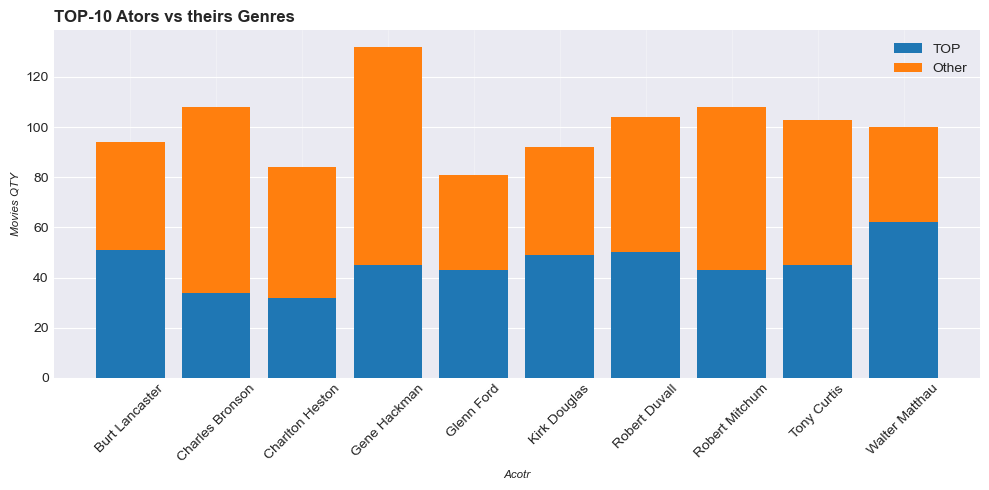

In [158]:
# Оціни пропорції для кожного актора у вигляді стовпчикової діаграми
plt.figure(figsize=(10, 5))

plt.bar(actor_gen_counts.index, actor_gen_counts['TOP'], label='TOP')
plt.bar(actor_gen_counts.index, actor_gen_counts['Other'], bottom = actor_gen_counts['TOP'], label='Other')

plt.title('TOP-10 Ators vs theirs Genres', fontsize='large', loc='left', fontweight='bold')
plt.ylabel('Movies QTY', fontsize='small', fontstyle='italic')
plt.xlabel('Acotr', fontsize='small', fontstyle='italic')
plt.legend()
plt.xticks(rotation=45)
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()